<a href="https://colab.research.google.com/github/Bloop15/DL-2026-2027/blob/main/Different_CNN_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
X_train, X_test= X_train/255.0, X_test/255.0

In [4]:
def standard_cnn():
  model= models.Sequential([
      layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(64, (3,3), activation='relu', padding='same'),
      layers.GlobalAveragePooling2D(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  return model

In [5]:
def depthwise_separable_cnn():
  model=models.Sequential([
      layers.SeparableConv2D(32, (5,3), activation='relu', padding='same', input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),
      layers.SeparableConv2D(64, (3,3), activation='relu', padding='same'),
      layers.GlobalAveragePooling2D(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  return model

In [6]:
def dilated_cnn():
  model= models.Sequential([
      layers.Conv2D(32, (3,3), activation='relu', padding='same', dilation_rate= 2, input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(64, (3,3), activation='relu', padding='same', dilation_rate= 2),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(128, (3,3), activation='relu', padding='same', dilation_rate= 2),
      layers.GlobalAveragePooling2D(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  return model

In [7]:
def train_and_evaluate(model, name):
  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  print(f"\nTraining {name} model...")
  history= model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

  test_loss, test_acc= model.evaluate(X_test, y_test, verbose=2)
  print(f"{name} Test Accuracy: {test_acc:.4f}")

  return history

In [8]:
model_dict={
    'Standard CNN': standard_cnn(),
    'Depthwise Separable CNN': depthwise_separable_cnn(),
    'Dilated CNN': dilated_cnn()
}

histories={}
for name, model in model_dict.items():
  histories[name]= train_and_evaluate(model, name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(



Training Standard CNN model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 105ms/step - accuracy: 0.2598 - loss: 1.9457 - val_accuracy: 0.3128 - val_loss: 1.7860
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.3459 - loss: 1.7212 - val_accuracy: 0.3627 - val_loss: 1.6752
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 96ms/step - accuracy: 0.3805 - loss: 1.6485 - val_accuracy: 0.4067 - val_loss: 1.5880
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 102ms/step - accuracy: 0.4105 - loss: 1.5825 - val_accuracy: 0.4253 - val_loss: 1.5375
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 98ms/step - accuracy: 0.4407 - loss: 1.5167 - val_accuracy: 0.4619 - val_loss: 1.4618
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 96ms/step - accuracy: 0.4650 - loss: 1.4635 - val_accuracy: 0.4589 - val_loss: 1.4847
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.4833 - loss: 1.4185 - val_accuracy: 0.4805 - val_loss: 1.4194
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step -

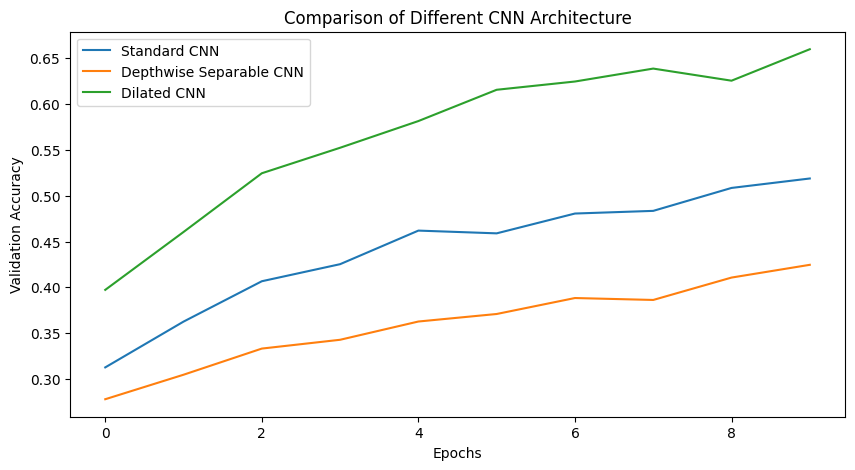

In [9]:
plt.figure(figsize=(10,5))
for name, history in histories.items():
  plt.plot(history.history['val_accuracy'], label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Comparison of Different CNN Architecture")
plt.show()